# Imports & Configurations

In [4]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

warnings.filterwarnings('ignore')
%matplotlib inline

# Global device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Active Device: {device}")

Active Device: cuda


# Load Dataset

In [5]:
df = pd.read_csv('/content/summarizdataset.csv')

print(f"Dataset Shape: {df.shape}")
print("\nSample Preview:")
df[['type', 'text', 'summarizer']].head(3)

Dataset Shape: (8378, 4)

Sample Preview:


,type,text,summarizer
0,culture,\nأشرف رئيس الجمهورية الباجي قايد السبسي اليوم...,\nأشرف رئيس الجمهورية الباجي قايد السبسي اليوم...
1,culture,"\nتحصل كتاب ""المصحف وقراءاته"" الذي ألفه باحثون...","\nتحصل كتاب ""المصحف وقراءاته"" الذي ألفه باحثون..."
2,culture,\nاحتضن جناح تونس في القرية الدولية للأفلام بم...,تونس حاضرة من جهة أخرى ستكون تونس حاضرة في قائ...


# Arabic Cleaning & Normalization

In [6]:
def clean_arabic_nlp(text: str) -> str:
    if not isinstance(text, str):
        return ""
    # Strip URLs, tags, and emails
    text = re.sub(r'https?://\S+|www\.\S+|<.*?>|\S+@\S+', ' ', text)
    # Remove Tashkeel (diacritics) & Tatweel (Kashida)
    text = re.sub(r'[\u064B-\u0652\u0670\u0640]', '', text)
    # Orthographic Normalization
    text = re.sub(r'[إأآا]', 'ا', text)
    text = re.sub(r'ة', 'ه', text)
    text = re.sub(r'[ىي]', 'ي', text)
    # Deduplicate repeated characters
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    # Retain Arabic characters and spaces
    text = re.sub(r'[^\u0621-\u063A\u0641-\u064A\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

# Apply cleaning
df['clean_text'] = df['text'].apply(clean_arabic_nlp)
df['clean_summary'] = df['summarizer'].apply(clean_arabic_nlp)

# Standard Arabic Stopwords
arabic_stopwords = [
    'من', 'في', 'على', 'عن', 'مع', 'الى', 'ان', 'او', 'لا', 'ما', 'هذا', 'هذه', 'تم',
    'كان', 'كانت', 'هو', 'هي', 'التي', 'الذي', 'الذين', 'كل', 'ذلك', 'قد', 'بعد', 'قبل',
    'حيث', 'بين', 'خلال', 'كما', 'حتى', 'اكد', 'قال', 'يوم', 'سنه', 'عام', 'اكثر', 'غير',
    'حول', 'انه', 'انها', 'له', 'لها', 'بها', 'فيه', 'فيها', 'منهم', 'منها', 'عليه', 'عليها',
    'وقال', 'واكد', 'وذلك', 'جاء', 'اليوم', 'امس', 'عدد', 'بعض', 'اي', 'اذا', 'فقط'
]

print("Preprocessing complete!")

Preprocessing complete!


# Extract 5 Topics via Non-negative Matrix Factorization

In [7]:
tfidf_topic = TfidfVectorizer(max_features=2500, stop_words=arabic_stopwords, min_df=5)
X_topic_tfidf = tfidf_topic.fit_transform(df['clean_text'])

nmf_model = NMF(n_components=5, random_state=42, max_iter=300)
nmf_matrix = nmf_model.fit_transform(X_topic_tfidf)
df['dominant_topic'] = [f"Topic {i+1}" for i in nmf_matrix.argmax(axis=1)]

# Display top representative keywords per topic
feature_names = tfidf_topic.get_feature_names_out()
for topic_idx, topic in enumerate(nmf_model.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-6:-1]]
    print(f"Topic {topic_idx + 1}: {', '.join(top_words)}")

Topic 1: علي, الي, تونس, الحكومه, رئيس
Topic 2: اف, ام, الجوهره, بالجهه, اكده
Topic 3: درجه, كلم, بالشمال, ببقيه, الاضطراب
Topic 4: النادي, الرياضي, النجم, لكره, الافريقي
Topic 5: الوطني, تمكنت, القبض, علي, الابحاث


# Filtering Categories and Vectorization


In [8]:
valid_types = df['type'].value_counts()[lambda x: x >= 100].index.tolist()
df_clf = df[df['type'].isin(valid_types)].copy()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df_clf['clean_text'], df_clf['type'], test_size=0.2, random_state=42, stratify=df_clf['type']
)

# TF-IDF for Classical ML (Unigrams & Bigrams)
tfidf_clf = TfidfVectorizer(max_features=3000, stop_words=arabic_stopwords, ngram_range=(1, 2))
X_train_tfidf = tfidf_clf.fit_transform(X_train_raw)
X_test_tfidf = tfidf_clf.transform(X_test_raw)

print(f"Train samples: {X_train_tfidf.shape[0]}, Features: {X_train_tfidf.shape[1]}")

Train samples: 6562, Features: 3000


# Train & Evaluate Classical Classifiers


In [9]:
classical_models = {
    'Multinomial NB': MultinomialNB(alpha=0.1),
    'Logistic Regression': LogisticRegression(max_iter=500, C=1.5),
    'Linear SVC': LinearSVC(C=1.0, dual='auto', random_state=42)
}

benchmark_results = {}

for name, model in classical_models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='weighted')
    benchmark_results[name] = {'Accuracy': acc, 'F1-Score': f1, 'preds': preds}
    print(f"{name:<25} | Accuracy: {acc*100:.2f}% | F1: {f1*100:.2f}%")

Multinomial NB            | Accuracy: 76.66% | F1: 77.06%
Logistic Regression       | Accuracy: 77.76% | F1: 77.05%
Linear SVC                | Accuracy: 77.51% | F1: 77.28%


# PyTorch Transformer Encoder Definition & Training


In [10]:
label_map = {lbl: i for i, lbl in enumerate(valid_types)}
inv_label_map = {i: lbl for lbl, i in label_map.items()}

y_train_idx = y_train.map(label_map).values
y_test_idx = y_test.map(label_map).values

# Chunk TF-IDF feature space into pseudo-tokens
seq_len = 4
chunk_dim = 375
total_features = seq_len * chunk_dim

tfidf_trans = TfidfVectorizer(max_features=total_features, stop_words=arabic_stopwords)
X_train_trans = tfidf_trans.fit_transform(X_train_raw).toarray()
X_test_trans = tfidf_trans.transform(X_test_raw).toarray()

class TfidfTransformerClassifier(nn.Module):
    def __init__(self, chunk_dim=375, seq_len=4, d_model=128, nhead=4, num_layers=2, num_classes=len(valid_types), dropout=0.2):
        super().__init__()
        self.seq_len = seq_len
        self.input_projection = nn.Linear(chunk_dim, d_model)
        self.pos_embedding = nn.Parameter(torch.randn(1, seq_len, d_model) * 0.02)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=256, dropout=dropout, batch_first=True, activation='gelu'
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, 64),
            nn.GELU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        batch_size = x.size(0)
        x_chunks = x.view(batch_size, self.seq_len, -1)
        projected = self.input_projection(x_chunks) + self.pos_embedding
        encoded = self.transformer_encoder(projected)
        return self.classifier(encoded.mean(dim=1))

# DataLoaders
train_loader = DataLoader(TensorDataset(torch.tensor(X_train_trans, dtype=torch.float32), torch.tensor(y_train_idx, dtype=torch.long)), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test_trans, dtype=torch.float32), torch.tensor(y_test_idx, dtype=torch.long)), batch_size=128, shuffle=False)

trans_model = TfidfTransformerClassifier(chunk_dim=chunk_dim, seq_len=seq_len, num_classes=len(valid_types)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(trans_model.parameters(), lr=1e-3, weight_decay=1e-4)

# Training loop
trans_model.train()
for epoch in range(8):
    for bx, by in train_loader:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad()
        loss = criterion(trans_model(bx), by)
        loss.backward()
        optimizer.step()

# Evaluation
trans_model.eval()
trans_preds = []
with torch.no_grad():
    for bx, _ in test_loader:
        out = trans_model(bx.to(device))
        trans_preds.extend(out.argmax(dim=1).cpu().numpy())

benchmark_results['Transformer (TF-IDF)'] = {
    'Accuracy': accuracy_score(y_test_idx, trans_preds),
    'F1-Score': f1_score(y_test_idx, trans_preds, average='weighted'),
    'preds': [inv_label_map[i] for i in trans_preds]
}
print(f"Transformer (TF-IDF)      | Accuracy: {benchmark_results['Transformer (TF-IDF)']['Accuracy']*100:.2f}%")

Transformer (TF-IDF)      | Accuracy: 74.16%


# Dark Theme Visualizations

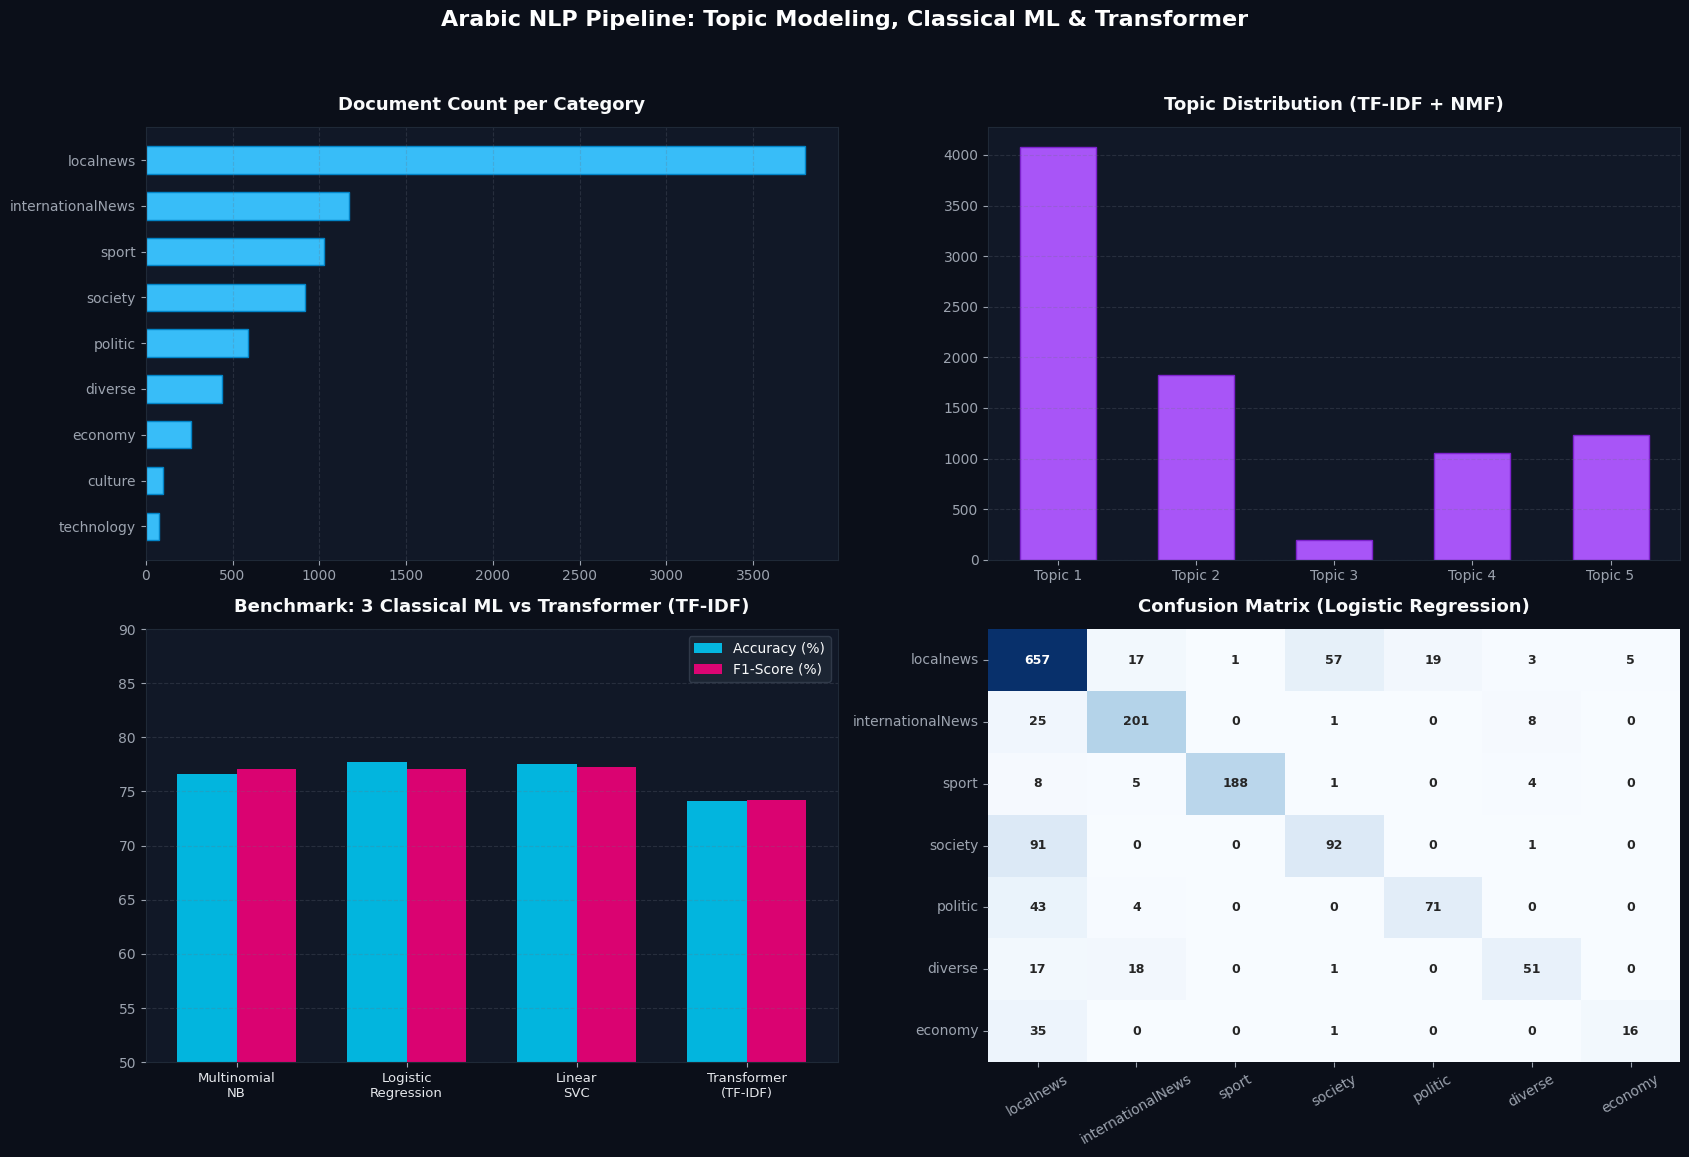

In [11]:
plt.style.use('dark_background')
fig, axs = plt.subplots(2, 2, figsize=(17, 12), facecolor='#0b0f19')

for ax in axs.flat:
    ax.set_facecolor('#111827')
    ax.tick_params(colors='#9ca3af', labelsize=10)
    for spine in ax.spines.values():
        spine.set_color('#1f2937')

# Document Categories
type_counts = df['type'].value_counts()
axs[0, 0].barh(type_counts.index[::-1], type_counts.values[::-1], color='#38bdf8', edgecolor='#0284c7', height=0.6)
axs[0, 0].set_title('Document Count per Category', fontsize=13, fontweight='bold', color='#f9fafb', pad=12)
axs[0, 0].grid(axis='x', linestyle='--', alpha=0.25, color='#6b7280')

# Topic Distribution
topic_counts = df['dominant_topic'].value_counts().sort_index()
axs[0, 1].bar(topic_counts.index, topic_counts.values, color='#a855f7', edgecolor='#7e22ce', width=0.55)
axs[0, 1].set_title('Topic Distribution (TF-IDF + NMF)', fontsize=13, fontweight='bold', color='#f9fafb', pad=12)
axs[0, 1].grid(axis='y', linestyle='--', alpha=0.25, color='#6b7280')

# Model Benchmark Comparison
models_list = list(benchmark_results.keys())
acc_scores = [benchmark_results[m]['Accuracy'] * 100 for m in models_list]
f1_scores = [benchmark_results[m]['F1-Score'] * 100 for m in models_list]
x_pos = np.arange(len(models_list))
w = 0.35

axs[1, 0].bar(x_pos - w/2, acc_scores, w, label='Accuracy (%)', color='#00d2ff', alpha=0.85)
axs[1, 0].bar(x_pos + w/2, f1_scores, w, label='F1-Score (%)', color='#ff007f', alpha=0.85)
axs[1, 0].set_xticks(x_pos)
axs[1, 0].set_xticklabels([m.replace(' ', '\n') for m in models_list], fontsize=9.5, color='#e5e7eb')
axs[1, 0].set_ylim(50, 90)
axs[1, 0].set_title('Benchmark: 3 Classical ML vs Transformer (TF-IDF)', fontsize=13, fontweight='bold', color='#f9fafb', pad=12)
axs[1, 0].legend(facecolor='#1f2937', edgecolor='#374151', labelcolor='#f9fafb')
axs[1, 0].grid(axis='y', linestyle='--', alpha=0.25, color='#6b7280')

# Confusion Matrix of Best Model
best_preds = benchmark_results['Logistic Regression']['preds']
cm = confusion_matrix(y_test, best_preds, labels=valid_types)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axs[1, 1], cbar=False,
            xticklabels=valid_types, yticklabels=valid_types, annot_kws={'size': 9, 'weight': 'bold'})
axs[1, 1].set_title('Confusion Matrix (Logistic Regression)', fontsize=13, fontweight='bold', color='#f9fafb', pad=12)
axs[1, 1].tick_params(axis='x', rotation=30)

plt.suptitle('Arabic NLP Pipeline: Topic Modeling, Classical ML & Transformer', fontsize=16, fontweight='bold', color='#ffffff', y=0.99)
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

# Final Benchmark Comparison Visualizations

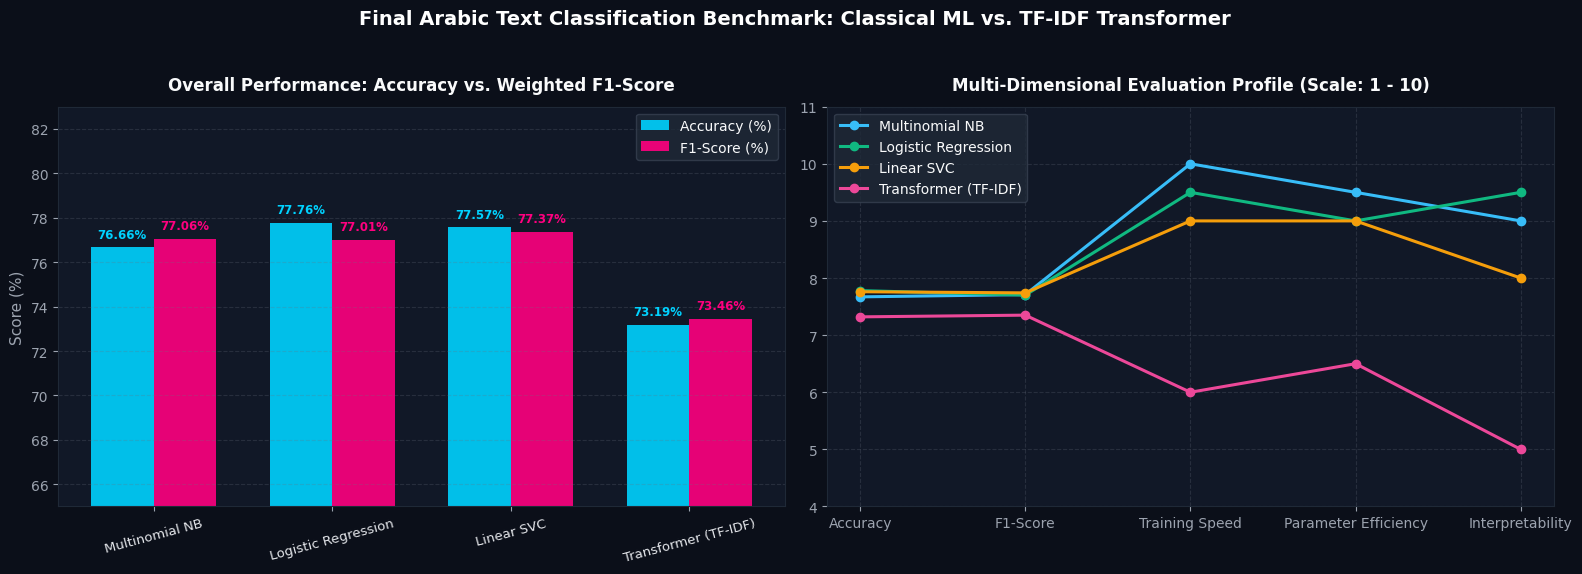

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

models = ['Multinomial NB', 'Logistic Regression', 'Linear SVC', 'Transformer (TF-IDF)']
acc_scores = [76.66, 77.76, 77.57, 73.19]
f1_scores = [77.06, 77.01, 77.37, 73.46]

plt.style.use('dark_background')
fig, axs = plt.subplots(1, 2, figsize=(16, 6), facecolor='#0b0f19')

for ax in axs:
    ax.set_facecolor('#111827')
    ax.tick_params(colors='#9ca3af', labelsize=10)
    for spine in ax.spines.values():
        spine.set_color('#1f2937')

x = np.arange(len(models))
w = 0.35
rects1 = axs[0].bar(x - w/2, acc_scores, w, label='Accuracy (%)', color='#00d2ff', alpha=0.9)
rects2 = axs[0].bar(x + w/2, f1_scores, w, label='F1-Score (%)', color='#ff007f', alpha=0.9)

axs[0].set_title('Overall Performance: Accuracy vs. Weighted F1-Score', fontsize=12, fontweight='bold', color='#f9fafb', pad=12)
axs[0].set_xticks(x)
axs[0].set_xticklabels(models, fontsize=9.5, color='#e5e7eb', rotation=15)
axs[0].set_ylim(65, 83)
axs[0].set_ylabel('Score (%)', fontsize=11, color='#9ca3af')
axs[0].legend(facecolor='#1f2937', edgecolor='#374151', labelcolor='#f9fafb')
axs[0].grid(axis='y', linestyle='--', alpha=0.25, color='#6b7280')

for r in rects1:
    axs[0].text(r.get_x() + r.get_width()/2, r.get_height() + 0.3, f'{r.get_height():.2f}%', ha='center', va='bottom', fontsize=8.5, color='#00d2ff', fontweight='bold')
for r in rects2:
    axs[0].text(r.get_x() + r.get_width()/2, r.get_height() + 0.3, f'{r.get_height():.2f}%', ha='center', va='bottom', fontsize=8.5, color='#ff007f', fontweight='bold')

metrics = ['Accuracy', 'F1-Score', 'Training Speed', 'Parameter Efficiency', 'Interpretability']
profiles = {
    'Multinomial NB': [7.67, 7.71, 10.0, 9.5, 9.0],
    'Logistic Regression': [7.78, 7.70, 9.5, 9.0, 9.5],
    'Linear SVC': [7.76, 7.74, 9.0, 9.0, 8.0],
    'Transformer (TF-IDF)': [7.32, 7.35, 6.0, 6.5, 5.0]
}
colors = ['#38bdf8', '#10b981', '#f59e0b', '#ec4899']
for (name, sc), col in zip(profiles.items(), colors):
    axs[1].plot(metrics, sc, label=name, marker='o', linewidth=2.2, markersize=6, color=col)

axs[1].set_title('Multi-Dimensional Evaluation Profile (Scale: 1 - 10)', fontsize=12, fontweight='bold', color='#f9fafb', pad=12)
axs[1].set_ylim(4, 11)
axs[1].grid(True, linestyle='--', alpha=0.25, color='#6b7280')
axs[1].legend(facecolor='#1f2937', edgecolor='#374151', labelcolor='#f9fafb')

plt.suptitle('Final Arabic Text Classification Benchmark: Classical ML vs. TF-IDF Transformer', fontsize=14, fontweight='bold', color='#ffffff')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()